In [50]:
import pandas as pd
import numpy as np

from LIF_SNN_test_new import SNNLayer

**Parameters**

In [60]:
# Input/Output size
n_inputs = 16
n_outputs = 3

# Training params
n_epochs = 50

# Neuron hyperparameters
beta = 0.90
threshold = 3.0
reset = 0.0

# Synapse parameters
learning_rate = 0.1
initial_weight = None
tau_pre = 2
tau_post = 2
tau_e = 10
A_plus = 0.1
A_minus = 0.1
min_weight = 0.05
max_weight = 1.0

# Setting up 
neuron_params = {"beta":beta, "threshold":threshold, "reset":reset}
synapse_params = {"learning_rate":learning_rate, "w_init":initial_weight, "tau_pre":tau_pre, "tau_post":tau_post, "tau_e":tau_e, "A_plus":A_plus, "A_minus":A_minus, "w_min":min_weight, "w_max":max_weight}

**Initialize network**

In [61]:
SNN = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs, synapse_params=synapse_params, neuron_params=neuron_params)

**Test data**

In [62]:
spiketrains = pd.read_csv("Frame_test_spiketrains.csv")

test_dist_train = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 
                   0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
                   0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

test_obj_req = [
    [0, 0, 0],  # 0
    [0, 0, 0],  # 1
    [0, 0, 0],  # 2
    [0, 0, 0],  # 3
    [0, 0, 0],  # 4
    [0, 0, 0],  # 5
    [0, 0, 0],  # 6
    [0, 0, 0],  # 7
    [0, 0, 0],  # 8
    [0, 0, 0],  # 9
    [0, 0, 0],  # 10
    [0, 0, 0],  # 11
    [0, 0, 0],  # 12
    [0, 0, 0],  # 13
    [0, 0, 0],  # 14
    [1, 0, 0],  # 15 - Object detected LEFT
    [1, 0, 0],  # 16
    [1, 0, 0],  # 17
    [1, 0, 0],  # 18
    [1, 0, 0],  # 19
    [1, 0, 0],  # 20
    [1, 0, 0],  # 21
    [1, 0, 0],  # 22
    [1, 0, 0],  # 23
    [1, 0, 0],  # 24
    [0, 1, 0],  # 25 - Object detected CENTRE
    [0, 1, 0],  # 26
    [0, 1, 0],  # 27
    [0, 1, 0],  # 28
    [0, 1, 0],  # 29
    [0, 1, 0],  # 30
    [0, 1, 0],  # 31
    [0, 0, 1],  # 32 - Object detected RIGHT
    [0, 0, 1],  # 33
    [0, 0, 1],  # 34
    [0, 0, 1],  # 35
    [0, 0, 1],  # 36 
    [0, 0, 1],  # 37
    [0, 0, 1],  # 38
    [0, 0, 1],  # 39
    [0, 1, 1],  # 40 - Object detected CENTRE again
    [0, 1, 0],  # 41
    [0, 1, 0],  # 42
    [0, 1, 0],  # 43
    [0, 1, 0],  # 44
    [0, 1, 0],  # 45
    [0, 1, 0],  # 46
    [0, 1, 0],  # 47
    [0, 1, 0],  # 48
    [0, 1, 0],  # 49
]

correct_outputs = []
for i in range(len(test_obj_req)):
    obj_l, obj_c, obj_r = test_obj_req[i]
    
    if obj_r:
        correct_outputs.append(2)      # object right → turn right
    elif obj_l:
        correct_outputs.append(1)      # object left → turn left
    elif obj_c or test_dist_train[i]:
        correct_outputs.append(1)      # object center or close → forward
    else:
        correct_outputs.append(1)      # nothing → forward/explore

input_spikes = []
for i in range(len(spiketrains)):
    row = spiketrains.iloc[i].tolist() + [test_dist_train[i]] + test_obj_req[i]
    input_spikes.append(row)

**Logging network activity**

In [63]:
# Initialize history lists
mem_hist = []
spike_hist = []
target_hist = []
weight_hist = []

n_correct = 0

**Run network**

In [64]:
# Repeat test for n epochs
for n in range(n_epochs):
    SNN.reset_state()
    # Iterate through spikes in each timestep
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):

        # Forward pass with current timestep
        output_spikes = SNN.forward(input_spikes=current_spikes)

        # Find the "winning" neuron of current timestep
        winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

        # Check correct
        if winner_idx == correct_output:
            dopamine = 1.0

            ### Debug ###
            n_correct += 1.0
        else:
            dopamine = -1.0

        # Apply reward
        SNN.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

        
        # Log results
        mem_hist.append([n.mem for n in SNN.neurons])
        spike_hist.append([n.spk for n in SNN.neurons])
        target_hist.append(correct_output)
        weight_hist.append(SNN.get_weights().copy())


    # Print results for each epoch
    print(f"--- Epoch ({n}) ---")
    print("Correct outputs:", n_correct)
    print()
    n_correct = 0


--- Epoch (0) ---
Correct outputs: 21.0

--- Epoch (1) ---
Correct outputs: 33.0

--- Epoch (2) ---
Correct outputs: 35.0

--- Epoch (3) ---
Correct outputs: 36.0

--- Epoch (4) ---
Correct outputs: 37.0

--- Epoch (5) ---
Correct outputs: 38.0

--- Epoch (6) ---
Correct outputs: 38.0

--- Epoch (7) ---
Correct outputs: 38.0

--- Epoch (8) ---
Correct outputs: 38.0

--- Epoch (9) ---
Correct outputs: 38.0

--- Epoch (10) ---
Correct outputs: 38.0

--- Epoch (11) ---
Correct outputs: 38.0

--- Epoch (12) ---
Correct outputs: 38.0

--- Epoch (13) ---
Correct outputs: 39.0

--- Epoch (14) ---
Correct outputs: 39.0

--- Epoch (15) ---
Correct outputs: 39.0

--- Epoch (16) ---
Correct outputs: 39.0

--- Epoch (17) ---
Correct outputs: 38.0

--- Epoch (18) ---
Correct outputs: 39.0

--- Epoch (19) ---
Correct outputs: 39.0

--- Epoch (20) ---
Correct outputs: 39.0

--- Epoch (21) ---
Correct outputs: 39.0

--- Epoch (22) ---
Correct outputs: 39.0

--- Epoch (23) ---
Correct outputs: 39.0

--

In [65]:
# Print final weights
import numpy as np
weights = SNN.get_weights()
print("Final weights (rows=output neurons, cols=inputs):")
print(np.round(weights, 3))

# Run one final pass to see per-sample decisions
print("\nPer-sample results:")
for i, (spikes, correct) in enumerate(zip(input_spikes, correct_outputs)):
    out = SNN.forward(input_spikes=spikes)
    winner = SNN.winner_takes_all(out)
    mems = [round(n.mem, 3) for n in SNN.neurons]
    print(f"  Sample {i}: winner={winner} correct={correct} {'✓' if winner==correct else '✗'} spikes={out} mems={mems}")

Final weights (rows=output neurons, cols=inputs):
[[0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.052 0.06
  0.05  0.05  0.058 0.082]
 [1.    0.812 0.847 0.884 0.907 0.902 0.692 0.903 0.909 1.    0.97  1.
  0.963 0.837 0.99  1.   ]
 [0.348 0.071 0.081 0.417 0.277 0.471 0.433 0.086 0.11  0.25  0.248 0.375
  0.339 0.195 0.427 0.217]]

Per-sample results:
  Sample 0: winner=0 correct=1 ✗ spikes=[0, 0, 0] mems=[np.float64(2.611), np.float64(0.0), np.float64(2.075)]
  Sample 1: winner=1 correct=1 ✓ spikes=[0, 1, 0] mems=[np.float64(2.552), 0.0, np.float64(2.706)]
  Sample 2: winner=1 correct=1 ✓ spikes=[0, 1, 1] mems=[np.float64(2.499), 0.0, 0.0]
  Sample 3: winner=1 correct=1 ✓ spikes=[0, 0, 0] mems=[np.float64(2.401), np.float64(2.854), np.float64(1.013)]
  Sample 4: winner=1 correct=1 ✓ spikes=[0, 1, 0] mems=[np.float64(2.413), 0.0, np.float64(2.429)]
  Sample 5: winner=1 correct=1 ✓ spikes=[0, 1, 1] mems=[np.float64(2.374), 0.0, 0.0]
  Sample 6: winner=1 correct=1 ✓ spik

In [66]:
import matplotlib.pyplot as plt
import numpy as np


def plot_snn_summary(mem_hist, spike_hist, target_hist, weight_hist=None,
                     threshold=2.5, n_epochs=1, samples_per_epoch=50,
                     plot_last_n_epochs=3):
    """
    Single combined plot: accuracy, weight evolution, membrane dynamics.
    """
    time_steps = len(mem_hist)
    num_neurons = len(mem_hist[0])
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    neuron_labels = ['Neuron 0 (left)', 'Neuron 1 (forward)', 'Neuron 2 (right)']
    if num_neurons != 3:
        neuron_labels = [f'Neuron {i}' for i in range(num_neurons)]

    n_rows = 1 + num_neurons + num_neurons
    fig, axes = plt.subplots(n_rows, 1, figsize=(18, 3.2 * n_rows),
                              gridspec_kw={'hspace': 0.45})

    # ---- Accuracy ----
    ax = axes[0]
    if n_epochs > 1:
        epoch_acc = []
        for e in range(n_epochs):
            start = e * samples_per_epoch
            end = start + samples_per_epoch
            correct = 0
            for t in range(start, min(end, time_steps)):
                spks = spike_hist[t]
                spiking = [j for j, s in enumerate(spks) if s > 0]
                if len(spiking) == 1:
                    winner = spiking[0]
                elif len(spiking) > 1:
                    winner = spiking[0]
                else:
                    winner = int(np.argmax([mem_hist[t][j] for j in range(num_neurons)]))
                if winner == target_hist[t]:
                    correct += 1
            epoch_acc.append(correct / samples_per_epoch * 100)

        ax.plot(epoch_acc, marker='.', markersize=5, linewidth=1.2, color='#2ca02c')
        ax.axhline(y=100 / num_neurons, color='red', linestyle='--', alpha=0.5, label='Chance')
        ax.set_ylim(0, 105)
        ax.legend(fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("Training Accuracy per Epoch", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.tick_params(labelsize=10)

    # ---- Weight evolution ----
    if weight_hist is not None and len(weight_hist) > 0:
        n_inputs = weight_hist[0].shape[1]
        for j in range(num_neurons):
            ax = axes[1 + j]
            for i in range(n_inputs):
                w_over_time = [w[j, i] for w in weight_hist]
                ax.plot(w_over_time, linewidth=0.8, alpha=0.75)

            ax.set_title(f"{neuron_labels[j]} — Weights", fontsize=12, fontweight='bold')
            ax.set_ylabel("Weight", fontsize=11)
            ax.set_ylim(-0.02, 1.05)
            ax.grid(True, linestyle=':', alpha=0.4)
            ax.tick_params(labelsize=10)
        axes[num_neurons].set_xlabel("Timestep", fontsize=11)

    # ---- Membrane dynamics (last N epochs) ----
    last_start = max(0, (n_epochs - plot_last_n_epochs) * samples_per_epoch)
    mem_slice = mem_hist[last_start:]
    spike_slice = spike_hist[last_start:]
    target_slice = target_hist[last_start:]
    t_len = len(mem_slice)

    for j in range(num_neurons):
        ax = axes[1 + num_neurons + j]
        mems = [m[j] for m in mem_slice]
        spks = [s[j] for s in spike_slice]

        ax.plot(mems, color=colors[j % len(colors)], alpha=0.85, linewidth=1.0)
        ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.4, linewidth=0.8)

        # Spikes
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            ax.scatter(spike_times, [threshold] * len(spike_times),
                       color='red', marker='x', s=50, linewidths=1.5, zorder=5)

        # Target shading
        for t in range(t_len):
            if target_slice[t] == j:
                ax.axvspan(t, t + 1, color=colors[j % len(colors)], alpha=0.12)

        # Epoch boundaries
        for e in range(1, plot_last_n_epochs):
            boundary = e * samples_per_epoch
            if boundary < t_len:
                ax.axvline(x=boundary, color='gray', linestyle='-', alpha=0.4, linewidth=1)

        ax.set_title(f"{neuron_labels[j]} — Membrane (last {plot_last_n_epochs} epochs)",
                     fontsize=12, fontweight='bold')
        ax.set_ylabel("Membrane", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.tick_params(labelsize=10)

    axes[-1].set_xlabel("Timestep (relative)", fontsize=11)
    fig.suptitle("SNN Training Summary", fontsize=16, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_11627/1549364969.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


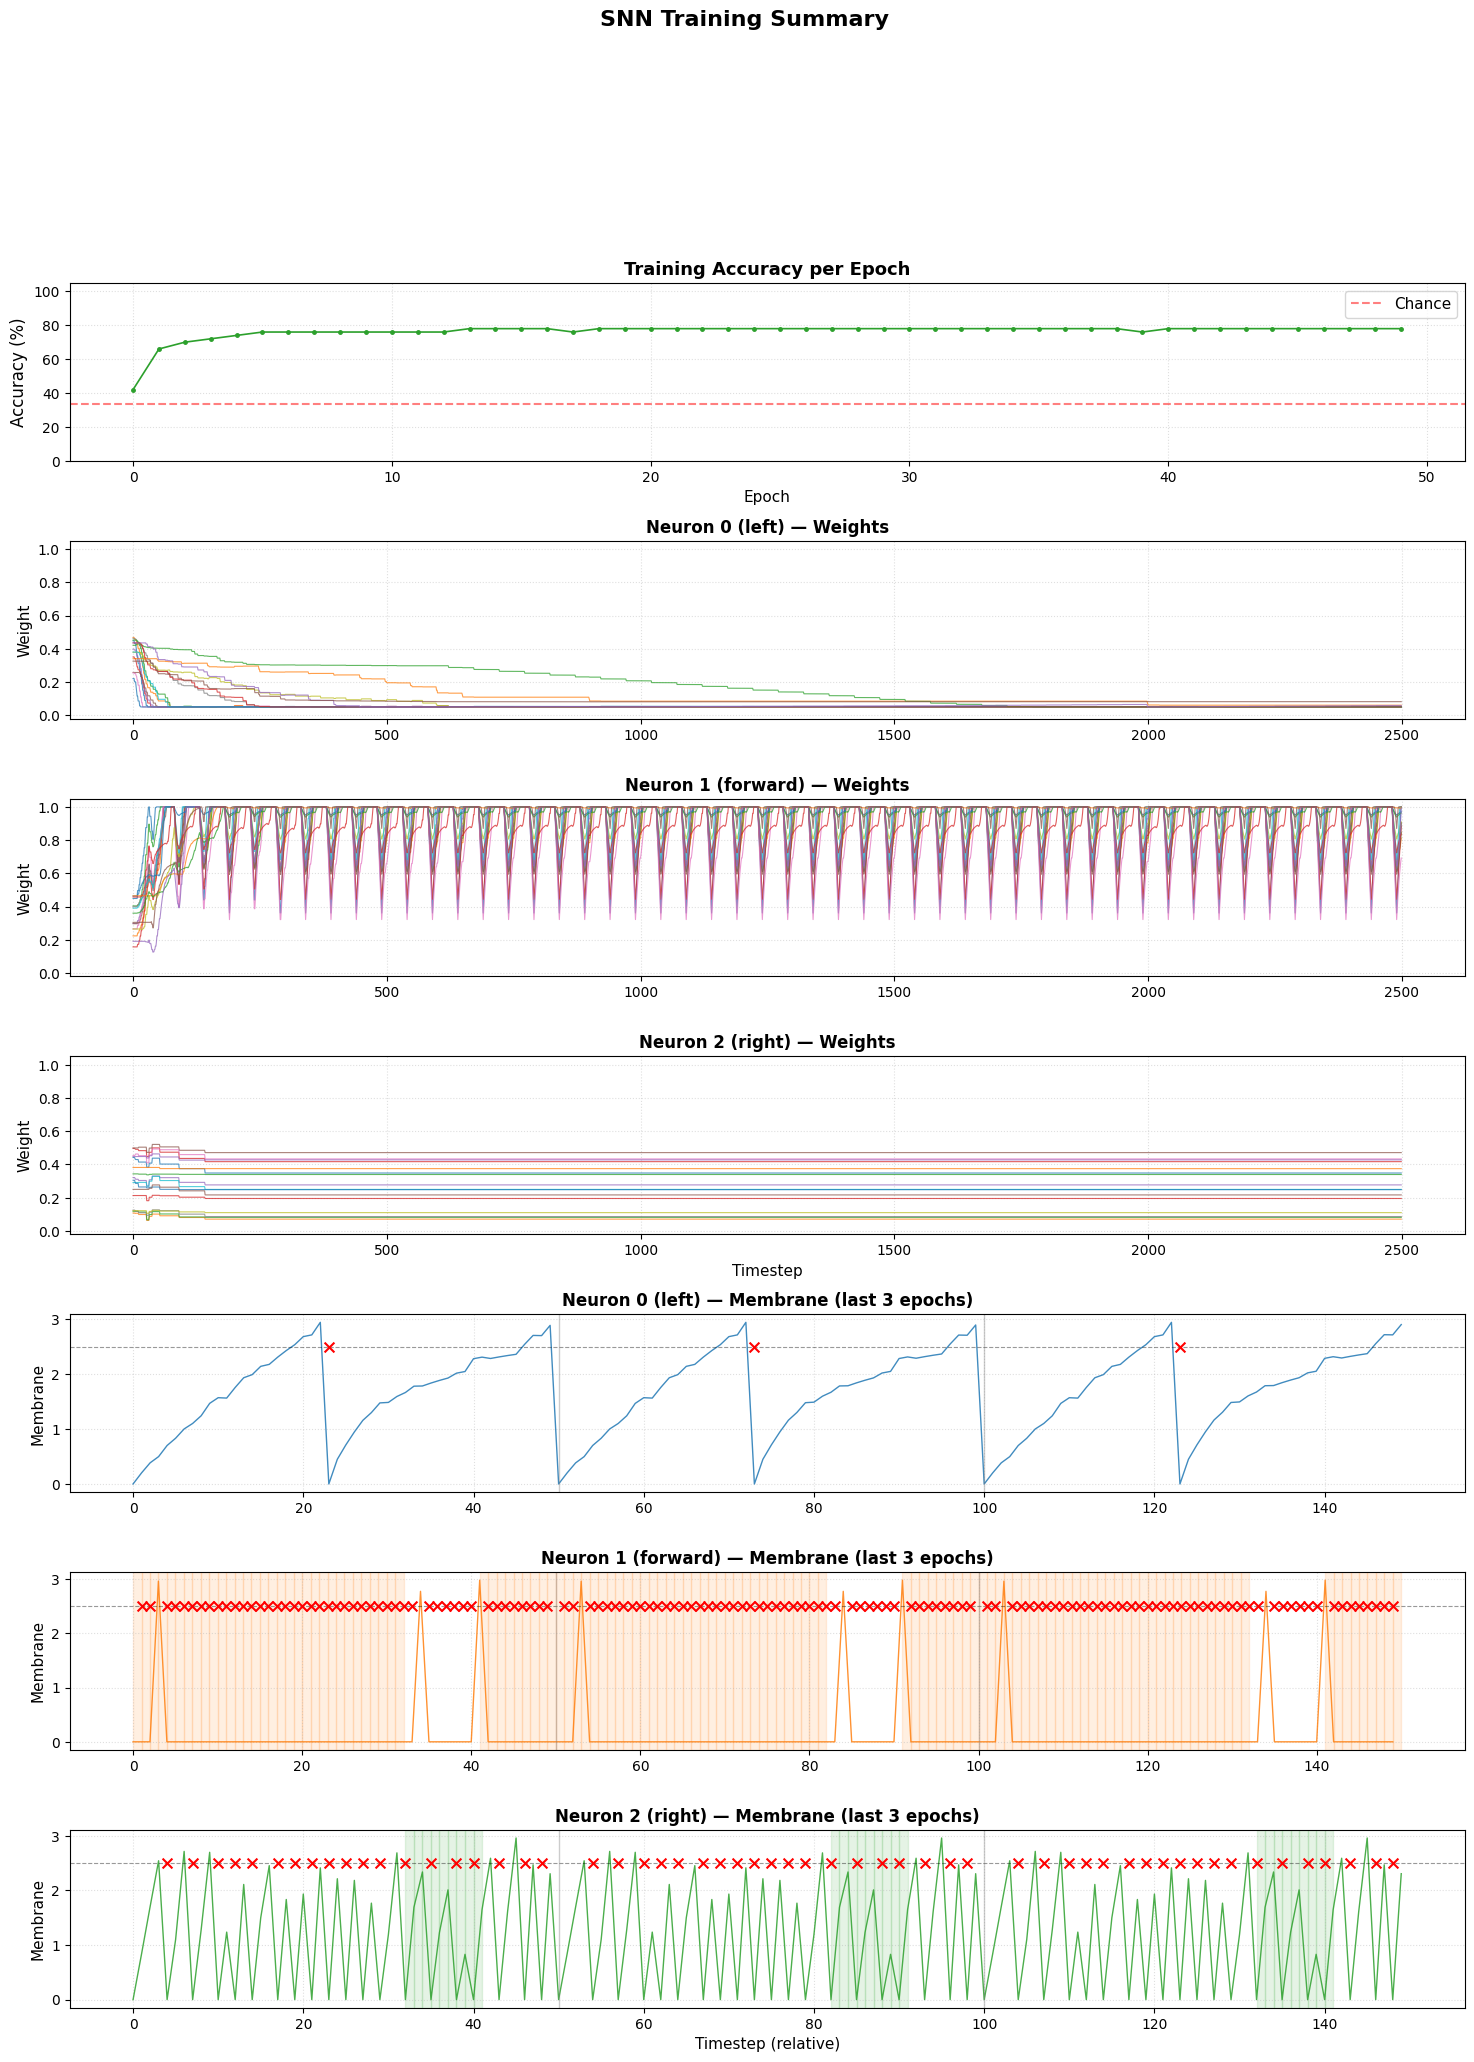

In [67]:
plot_snn_summary(mem_hist, spike_hist, target_hist, weight_hist,
                 threshold=2.5, n_epochs=n_epochs, 
                 samples_per_epoch=len(input_spikes),
                 plot_last_n_epochs=3)

In [68]:
"""
Interactive SNN Frame-by-Frame Visualizer
=========================================
Paste this entire cell into your Jupyter notebook.
Requires: mem_hist, spike_hist, target_hist, weight_hist, input_spikes, correct_outputs
already populated from your training loop.

Install if needed: pip install ipywidgets matplotlib
"""

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


def create_snn_visualizer(mem_hist, spike_hist, target_hist, weight_hist,
                          input_spikes, correct_outputs,
                          threshold=3, samples_per_epoch=50,
                          input_labels=None, output_labels=None):
    """
    Interactive frame-by-frame SNN visualizer.
    
    Args:
        All history lists from training loop.
        input_labels: Optional list of names for input neurons.
        output_labels: Optional list of names for output neurons.
    """
    total_steps = len(mem_hist)
    n_epochs = total_steps // samples_per_epoch
    num_inputs = len(input_spikes[0])
    num_outputs = len(mem_hist[0])

    if input_labels is None:
        input_labels = [f'KP{i}' for i in range(12)] + ['Dist'] + ['ObjL', 'ObjC', 'ObjR']
        if num_inputs != 16:
            input_labels = [f'In{i}' for i in range(num_inputs)]

    if output_labels is None:
        output_labels = ['Left (0)', 'Forward (1)', 'Right (2)']
        if num_outputs != 3:
            output_labels = [f'Out{i}' for i in range(num_outputs)]

    action_map = {0: '← LEFT', 1: '↑ FORWARD', 2: '→ RIGHT'}
    action_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
    neuron_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # --- Output area ---
    out = widgets.Output()

    def render_frame(step):
        with out:
            clear_output(wait=True)

            epoch = step // samples_per_epoch
            frame = step % samples_per_epoch
            mems = mem_hist[step]
            spks = spike_hist[step]
            target = target_hist[step]
            weights = weight_hist[step] if weight_hist else None
            inp = input_spikes[frame]

            # Determine winner
            spiking = [j for j, s in enumerate(spks) if s > 0]
            if len(spiking) == 1:
                winner = spiking[0]
            elif len(spiking) > 1:
                winner = spiking[0]
            else:
                winner = int(np.argmax(mems))

            correct = winner == target

            # --- Figure ---
            fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
            gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                                   height_ratios=[1.2, 1.5, 1.2])

            # === Header info ===
            ax_header = fig.add_subplot(gs[0, :])
            ax_header.set_facecolor('#0d1117')
            ax_header.axis('off')

            result_color = '#4ade80' if correct else '#f87171'
            result_text = '✓ CORRECT' if correct else '✗ WRONG'

            header_text = (
                f"Epoch {epoch}  |  Frame {frame}  |  Step {step}/{total_steps-1}\n"
                f"Target: {action_map.get(target, str(target))}  |  "
                f"Winner: {action_map.get(winner, str(winner))}  |  "
            )
            ax_header.text(0.02, 0.7, header_text, transform=ax_header.transAxes,
                          fontsize=16, color='#c9d1d9', fontfamily='monospace',
                          verticalalignment='top')
            ax_header.text(0.72, 0.7, result_text, transform=ax_header.transAxes,
                          fontsize=22, color=result_color, fontweight='bold',
                          fontfamily='monospace', verticalalignment='top')

            # === Input spikes (left panel) ===
            ax_inp = fig.add_subplot(gs[1, 0])
            ax_inp.set_facecolor('#161b22')
            y_pos = np.arange(num_inputs)
            bar_colors = ['#58a6ff' if v > 0 else '#21262d' for v in inp]
            ax_inp.barh(y_pos, inp, color=bar_colors, height=0.7, edgecolor='#30363d')
            ax_inp.set_yticks(y_pos)
            ax_inp.set_yticklabels(input_labels, fontsize=9, color='#c9d1d9', fontfamily='monospace')
            ax_inp.set_xlim(-0.1, 1.5)
            ax_inp.set_title('Input Spikes', fontsize=13, color='#c9d1d9',
                            fontweight='bold', pad=10)
            ax_inp.tick_params(colors='#484f58', labelsize=9)
            ax_inp.spines[:].set_color('#30363d')
            ax_inp.invert_yaxis()

            # === Membrane potentials (center panel) ===
            ax_mem = fig.add_subplot(gs[1, 1])
            ax_mem.set_facecolor('#161b22')
            y_pos_out = np.arange(num_outputs)
            bar_colors_mem = []
            for j in range(num_outputs):
                if spks[j]:
                    bar_colors_mem.append('#f87171')  # fired = red
                elif j == winner:
                    bar_colors_mem.append(neuron_colors[j % len(neuron_colors)])
                else:
                    bar_colors_mem.append('#484f58')

            bars = ax_mem.barh(y_pos_out, mems, color=bar_colors_mem, height=0.6,
                              edgecolor='#30363d', linewidth=1.5)
            ax_mem.axvline(x=threshold, color='#f0883e', linestyle='--',
                          linewidth=2, alpha=0.8, label=f'θ = {threshold}')

            # Labels on bars
            for j, (m, s) in enumerate(zip(mems, spks)):
                label = f'{m:.2f} ⚡' if s else f'{m:.2f}'
                ax_mem.text(max(m, 0) + 0.05, j, label, va='center',
                           fontsize=11, color='#c9d1d9', fontfamily='monospace')

            ax_mem.set_yticks(y_pos_out)
            ax_mem.set_yticklabels(output_labels, fontsize=11, color='#c9d1d9', fontfamily='monospace')
            ax_mem.set_xlim(0, threshold * 1.4)
            ax_mem.set_title('Membrane Potentials', fontsize=13, color='#c9d1d9',
                            fontweight='bold', pad=10)
            ax_mem.legend(fontsize=10, loc='lower right', facecolor='#161b22',
                         edgecolor='#30363d', labelcolor='#c9d1d9')
            ax_mem.tick_params(colors='#484f58', labelsize=10)
            ax_mem.spines[:].set_color('#30363d')
            ax_mem.invert_yaxis()

            # === Weight heatmap (right panel) ===
            if weights is not None:
                ax_w = fig.add_subplot(gs[1, 2])
                ax_w.set_facecolor('#161b22')
                im = ax_w.imshow(weights, aspect='auto', cmap='inferno',
                                vmin=0, vmax=1.0, interpolation='nearest')
                ax_w.set_yticks(range(num_outputs))
                ax_w.set_yticklabels(output_labels, fontsize=10, color='#c9d1d9', fontfamily='monospace')
                ax_w.set_xticks(range(num_inputs))
                ax_w.set_xticklabels(input_labels, fontsize=7, color='#c9d1d9',
                                    rotation=45, ha='right', fontfamily='monospace')
                ax_w.set_title('Weight Matrix', fontsize=13, color='#c9d1d9',
                              fontweight='bold', pad=10)
                ax_w.tick_params(colors='#484f58')
                ax_w.spines[:].set_color('#30363d')
                cbar = plt.colorbar(im, ax=ax_w, fraction=0.046, pad=0.04)
                cbar.ax.tick_params(colors='#c9d1d9', labelsize=9)

            # === Membrane history (bottom panel, trailing window) ===
            ax_trail = fig.add_subplot(gs[2, :])
            ax_trail.set_facecolor('#161b22')
            window = min(samples_per_epoch * 2, step + 1)
            start_t = max(0, step - window + 1)

            for j in range(num_outputs):
                trail_mems = [mem_hist[t][j] for t in range(start_t, step + 1)]
                trail_spks = [spike_hist[t][j] for t in range(start_t, step + 1)]
                x_range = range(start_t, step + 1)
                ax_trail.plot(x_range, trail_mems, color=neuron_colors[j % len(neuron_colors)],
                             linewidth=1.2, alpha=0.85, label=output_labels[j])

                sp_times = [t for t, s in zip(x_range, trail_spks) if s > 0]
                if sp_times:
                    ax_trail.scatter(sp_times, [threshold] * len(sp_times),
                                   color=neuron_colors[j % len(neuron_colors)],
                                   marker='v', s=35, zorder=5, alpha=0.9)

            # Target shading in trail
            for t in range(start_t, step + 1):
                tgt = target_hist[t]
                ax_trail.axvspan(t, t + 1,
                                color=neuron_colors[tgt % len(neuron_colors)], alpha=0.06)

            ax_trail.axhline(y=threshold, color='#f0883e', linestyle='--', linewidth=1.5, alpha=0.6)
            ax_trail.axvline(x=step, color='#f87171', linestyle='-', linewidth=2, alpha=0.7)
            ax_trail.set_title('Membrane History (trailing window)', fontsize=13,
                              color='#c9d1d9', fontweight='bold', pad=10)
            ax_trail.set_xlabel('Timestep', fontsize=11, color='#c9d1d9')
            ax_trail.set_ylabel('Membrane', fontsize=11, color='#c9d1d9')
            ax_trail.legend(fontsize=9, loc='upper left', facecolor='#161b22',
                           edgecolor='#30363d', labelcolor='#c9d1d9', ncol=num_outputs)
            ax_trail.tick_params(colors='#484f58', labelsize=10)
            ax_trail.spines[:].set_color('#30363d')

            plt.show()

    # --- Controls ---
    step_slider = widgets.IntSlider(
        value=0, min=0, max=total_steps - 1, step=1,
        description='Step:', continuous_update=False,
        layout=widgets.Layout(width='70%'),
        style={'description_width': '50px'}
    )

    epoch_slider = widgets.IntSlider(
        value=0, min=0, max=n_epochs - 1, step=1,
        description='Epoch:', continuous_update=False,
        layout=widgets.Layout(width='40%'),
        style={'description_width': '50px'}
    )

    frame_slider = widgets.IntSlider(
        value=0, min=0, max=samples_per_epoch - 1, step=1,
        description='Frame:', continuous_update=False,
        layout=widgets.Layout(width='40%'),
        style={'description_width': '50px'}
    )

    play_btn = widgets.Play(
        value=0, min=0, max=total_steps - 1, step=1,
        interval=300, description='▶',
        layout=widgets.Layout(width='60px')
    )

    speed_dropdown = widgets.Dropdown(
        options=[('Slow (500ms)', 500), ('Normal (300ms)', 300),
                 ('Fast (100ms)', 100), ('Very Fast (50ms)', 50)],
        value=300, description='Speed:',
        layout=widgets.Layout(width='200px'),
        style={'description_width': '50px'}
    )

    # Link play button to step slider
    widgets.jslink((play_btn, 'value'), (step_slider, 'value'))

    def on_speed_change(change):
        play_btn.interval = change['new']
    speed_dropdown.observe(on_speed_change, names='value')

    # Sync epoch/frame to step
    _updating = [False]

    def on_step_change(change):
        if _updating[0]:
            return
        _updating[0] = True
        s = change['new']
        epoch_slider.value = s // samples_per_epoch
        frame_slider.value = s % samples_per_epoch
        render_frame(s)
        _updating[0] = False

    def on_epoch_frame_change(change):
        if _updating[0]:
            return
        _updating[0] = True
        s = epoch_slider.value * samples_per_epoch + frame_slider.value
        step_slider.value = min(s, total_steps - 1)
        render_frame(min(s, total_steps - 1))
        _updating[0] = False

    step_slider.observe(on_step_change, names='value')
    epoch_slider.observe(on_epoch_frame_change, names='value')
    frame_slider.observe(on_epoch_frame_change, names='value')

    # Layout
    controls_top = widgets.HBox([play_btn, step_slider, speed_dropdown])
    controls_bottom = widgets.HBox([epoch_slider, frame_slider])
    ui = widgets.VBox([controls_top, controls_bottom, out])

    render_frame(0)
    display(ui)


# === RUN THIS ===
create_snn_visualizer(
    mem_hist=mem_hist,
    spike_hist=spike_hist,
    target_hist=target_hist,
    weight_hist=weight_hist,
    input_spikes=input_spikes,
    correct_outputs=correct_outputs,
    threshold=2.5,
    samples_per_epoch=len(input_spikes)
)